In [1]:
#Import neccessary python modules

%matplotlib inline
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter

from scipy.interpolate import UnivariateSpline 
from scipy.interpolate import interp1d 

from IPython.display import display, HTML

import copy
from astropy.io import fits
from scipy.optimize import minimize

import pandas as pd

In [9]:
#Create a list of all raw data files in the folder specified by spectraDir
spectraDir = '//macdiarmid/ASTR211/2024_McLellan1m/REDUCED_DATA/hd_39091/'
spectraFileList = [f for f in os.listdir(spectraDir) if f.endswith('.mat')]
spectraFileList.sort()


# A function to extract the orders from a .mat file, and apply barycentric correction.
def extractOrdersFromFile(filename):
    '''A function to extract a HERCULES spectrum from the .mat format files. Applies barycentric correction.
    
        inputs: filename (string)
        outputs: spectral orders (list)
                 julian date (float)'''
    
    #Use scipy loadmat function to load the .mat file
    dat = loadmat(filename)
    

    #The file contents are loaded into the dictionary 'dat', 
    #with the file contents saved in a key that corresponds 
    #to the filename. This part of the code extracts the
    #key for the dictionary from the file name
    fileString = filename[-12:-4]
    
    #Extract the Julian Date from the dictionary
    jD = dat[fileString][0,0][95][0][0]

    #Extract the barycentric correction from the dictionary
    baryCor = dat[fileString][0,0][-1][0][0]

    #Create an empty list that will hold the orders of the spectrum
    orders = []

    #Iterate through the dictionary and extract the spectral orders
    for i in range(len(dat[fileString][0,0])-8):
    
        #Extract the ith spectral orders
        data = dat[fileString][0,0][i]
    
        #Grab the wavelength from the extracted order and apply the 
        #barycentric correction
        wavelength = data[:,0]*(2.99792458e5 + baryCor)/(2.99792458e5)
        if len(data[0]) != 2:
            break
        #Grab the intensity from the extracted order
        intensity = data[:,1]

        #Pack the  barycentric corrected wavelength and intensity 
        #of the extracted spectral order into a tuple, then add that to the list 
        #of extracted orders
        orders.append((wavelength,intensity))

    
    return orders, jD



# A simple function to visulise spectra, including plotting multiple plots easily
def SpectrumPlot(orders, spectraid = None, xlim = [6500,7500], ylim = [0.0,2.0], figure_num = None):
    '''A function to plot a list of spectral orders. If more than one set of orders is supplied, 
            they can be identified with the idList input.

    inputs:  spectral orders    :   list of lists
             spectra id         :   list of strings
             figure_num         :   int
    outputs: none'''


    for i, spectra in enumerate(orders):
    #Create an empty figure
        if figure_num is not None:
            plt.figure(figure_num)
        else:
            plt.figure()
        
        #Set the x and y limits of the plot
        plt.ylim(ylim)
        plt.xlim(xlim)
        
        #Iterate through the orders of the selected spectrum and add them to the plot
        for j, data in enumerate(spectra):
            #Plot the order on the axis as wavelength v.s. intensity
            plt.plot(data[0],data[1])
        if spectraid is not None:
            plt.title(spectraid[i])
            
        #Update labels on plot
        plt.xlabel(r'Wavelength ($\AA$)')
        plt.ylabel('Relative Intensity')
        if figure_num is None:
            plt.show()


# Normalising each order
def normaliseOrders(orders,scale = 20,intensityLimit = 20.0,polynomialOrder = 4):
    '''A function to continuum normalise a list of orders. 
        The function chooses continuum points by maximum filtering the data and applying a direct threshold.
        The size of the maximum filter and the intensity threshold can be controlled by the relevant input 
        parameters. The continuum is determined by fitting a polynomial to the  previously selected continuum 
        points.The continuum points are first median filtered to remove any outliers, the median filter is the 
        same size as the maximum filter. The order of the polynomial can be controlled by the relevant input 
        parameter.

    inputs:  spectral orders (list)
             maximum/median filter scale (integer)
             intensity threshold (float)
             polynomial order (int)
    outputs: normalised spectral orders (list)'''
    
    #Create an empty list to hold the continuum normalised spectrum for each spectral order
    normalisedOrders = []

    #Iterate through the spectral orders...
    for i in range(len(orders)):

        #Grab the wavelength and intensity of the ith order
        wavelength = orders[i][0]
        intensity = orders[i][1]

        #Maxmimum filter the intensity, which finds the maxmimum in a window
        #of size scale centrered on each pixel
        maximaIntesnity = maximum_filter(intensity,scale)
        
        #Identify points in the intensity that are considered part of the continuum
        #by choosing points where the intensity is equal to the maximum filtered intensity 
        # (akin to choosing local maxima within the windows) that are also below a chosen 
        #intensity limit
        continuumMask = (maximaIntesnity == intensity)*(intensity < intensityLimit)
        
        #If the above process does not identify any continuum points, break the process
        if(np.all(~continuumMask)):
            print('Error: No Continuum Points Found. Try a different set of parameters')
            break
            
        #Fit a polynomial to the chosen continuum points. A median filter is applied to the chosen continuum 
        #points to exclude any outliers.
        continuumFit = np.polyfit(wavelength[continuumMask], median_filter(intensity[continuumMask],scale),polynomialOrder)


        #Apply the continuum normalisation to the spectral order, then add it to the list
        normalisedOrders.append((wavelength,intensity/np.polyval(continuumFit,wavelength)))
    
    return normalisedOrders



# Merging orders into one spectrum
def combineOrders(orders, smoothingWindow=10,scale=1.0):
    
    '''A function to combine the spectral orders into a single continuous spectrum.
        Where the orders overlap, a arctangent wavelength weighted mean is used.

    inputs:  spectral orders (list)

    outputs: combined spectrum (list)'''
    
    #Create empty lists to hold the spectral orders that are ready to be combined
    wavelengthList = []
    intensityList = []
    
    #Create a copy of the spectral orders so that the original orders are not altered
    iOrders = copy.deepcopy(orders)
    
    for i in range(len(iOrders)-1):
        
        
        #Determine the wavelength limits of the ith and i+1th spectral orders to 
        #determine the range of wavelengths that have the orders overlapping
        wavelengthLowBoundary = np.min(iOrders[i+1][0])
        wavelengthUpBoundary = np.max(iOrders[i][0])
        meanBoundaryWL = (wavelengthLowBoundary+wavelengthUpBoundary)/2.0
        

        #If the neighbouring orders overlap...
        if(wavelengthLowBoundary < wavelengthUpBoundary):


            #Copy the intensity and wavelength of the lower order into a dummy variable
            wavelengthLowerOrder = iOrders[i][0]
            intensityLowerOrder = iOrders[i][1]

            #Copy the intensity and wavelength of the higher order into a dummy variable
            wavelengthHigherOrder = iOrders[i+1][0]
            intensityHigherOrder = iOrders[i+1][1]


            #Select ot the data in the overlapping region from the higher and lower order
            lowOrderMask = (wavelengthLowerOrder <= wavelengthUpBoundary)*(wavelengthLowerOrder >= wavelengthLowBoundary)
            highOrderMask = (wavelengthHigherOrder <= wavelengthUpBoundary)*(wavelengthHigherOrder >= wavelengthLowBoundary)

            #Create a new common wavelength grid for the overlapping region
            overlapWavelength = np.linspace(wavelengthLowBoundary, wavelengthUpBoundary, np.max([np.sum(lowOrderMask), np.sum(highOrderMask)]))

            #Linearly interpolate the lower and higher order spectral orders onto the comman wavelength grid
            olintensityLOInterp = interp1d(wavelengthLowerOrder[lowOrderMask],intensityLowerOrder[lowOrderMask],kind='linear',bounds_error=False,fill_value='extrapolate')(overlapWavelength)
            olintensityHOInterp = interp1d(wavelengthHigherOrder[highOrderMask],intensityHigherOrder[highOrderMask],kind='linear',bounds_error=False,fill_value='extrapolate')(overlapWavelength)

            #Weight the overlapping orders using an arctangent function
            weights = np.arctan((overlapWavelength - meanBoundaryWL)/scale)/(np.pi) + 0.5

            #Calculate the new overlap as the weighted average between the overlapping orders
            overlapIntensity = weights*olintensityHOInterp + (1-weights)*olintensityLOInterp
            
            #Remove the overlapping region from the original spectral orders and add in the new weighted
            #average in the overlapping area
            lowOrderWL = np.concatenate((wavelengthLowerOrder[wavelengthLowerOrder<wavelengthLowBoundary],
                                          overlapWavelength[overlapWavelength < meanBoundaryWL ]))
            lowOrderI = np.concatenate((intensityLowerOrder[wavelengthLowerOrder<wavelengthLowBoundary],
                                          overlapIntensity[overlapWavelength < meanBoundaryWL ]))            
            iOrders[i] = (lowOrderWL,lowOrderI)            
            highOrderWL = np.concatenate((overlapWavelength[overlapWavelength >= meanBoundaryWL ],
                                          wavelengthHigherOrder[wavelengthHigherOrder>wavelengthUpBoundary]))
            highOrderI = np.concatenate((overlapIntensity[overlapWavelength >= meanBoundaryWL ],
                                         intensityHigherOrder[wavelengthHigherOrder>wavelengthUpBoundary]))
            iOrders[i+1] = (highOrderWL,highOrderI)


        

        #Add the spectral orders that are now ready to be combined to the list of 
        #spectral orders that are ready to be combined
        wavelengthList.append(iOrders[i][0])
        intensityList.append(iOrders[i][1])

            

    #Add the last spectral order
    wavelengthList.append(iOrders[-1][0])
    intensityList.append(iOrders[-1][1])
    
    #Concatenate the list of spectral orders into one combined spectrum
    combinedOrderList = [np.hstack(wavelengthList), np.hstack(intensityList)]
    
    return(combinedOrderList)


def correct_velocity(spectrum, velocity, segments=None):

   """Correct velocity in km/s."""
   # Speed of light in m/s
   c = 299792458.0
   # Correct wavelength scale for radial velocity
   # - Newtonian version:
   ##Radial/barycentric velocity from km/s to m/s
   ##velocity = velocity * 1000
   #spectrum['waveobs'] = spectrum['waveobs'] / ((velocity / c) + 1)
   
    # - Relativistic version:
   spectrum['waveobs'] = spectrum['waveobs'] * np.sqrt((1.-(velocity*1000.)/c)/(1.+(velocity*1000.)/c))
   return spectrum




In [10]:
def chi2(p,model,yData,xData,yErr):
    '''A function to calculate the chi squared test statistic for the Gaussian absorption line fitting'''
    m = model(p, xData)
    return np.sum((yData - m)**2/yErr**2)

def gaussianLine(p,x):
    '''A function to calculate a Gaussian absorption line. Returns y values of the fit associated to the input x values'''
    A, mu, sigma, C = p
    return(A*np.exp(-0.5*(x - mu)**2/sigma**2) + C)

def fitGaussianLine(spectrum, wavelengthWindow, lineName=None):
    
    '''A function to fit a single Gaussian to a fixed region of the spectrum. Multiple regions can be fitted
        with a single call by suppling a list of wavelength limits. By default, this function plots the result,
        this can be toggled off by setting plotFit = False.

    inputs: combined spectrum (list)
            fitting windows (tuple e.g (lambda_min,lambda_max), or list of tuples) 
            line name (list of string)

    outputs: pandas DataFrame of fitted parameters (ndarray with shape (len(wavelengthWindow),4))'''
    
    #Ceate empty lists to store the fitted parameters and errors
    fitList = []
    errorList = []
    
    #Grab the wavelength and intensity of the spectrum
    wavelength = spectrum[0]
    intensity = spectrum[1]
    
    #Create a mask to select only data in the wavelength window
    waveMask = (wavelength > np.min(wavelengthWindow))*(wavelength < np.max(wavelengthWindow) )

    #Use the mask to select only the data in the wavelength window
    wData = wavelength[waveMask]
    iData = intensity[waveMask]
    
    #Smartly choose initial guesses for the Guassian absorption lines parameters
    #mu: the central wavelength of the absorption line
    #A: the depth of the absorption line
    #C: the offset of the line from 0, should be about 1 (so it's on the continuum)
    #sigma: the width of the absorption line
    muGuess = wData[np.argmin(iData)]
    AGuess =  np.min(iData) - 1.0
    CGuess = 1.0
    sigmaGuess = 1.0
    
    #Estimate a value for the uncertainty in the intensity measurements
    yerrGuess = 0.01
    
    #Fit the Gaussian absorption line using scipys minimize function to minimize chi2 function.
    initialGuess = [AGuess,muGuess, sigmaGuess,CGuess]
    fit = minimize(chi2, x0=initialGuess, args = (gaussianLine,iData,wData,yerrGuess), method='BFGS')
    
    #Rescale the errorbars on the parameters to account for the fact that we don't
    #know what the error on the measuremed spectrum is
    #We do this by asserting that our fit has a reduced chi squared of ~1.
    mChi2 = chi2(fit.x,gaussianLine,iData,wData,yerrGuess)
    pErr = np.sqrt(np.diag(0.5*fit.hess_inv*mChi2))
    
    #Save the fitted parameters into a new variable
    pFit = fit.x

    #Create a new wavelength array for plotting the result
    plotLineX = np.linspace(pFit[1]-5*pFit[2],pFit[1]+5*pFit[2],1000)

    
    #If the result is being plotted and its the first window...

    
    #Add the fitted parameters and errors to the lists
    fitList.append(pFit)
    errorList.append(pErr)

    #Combine the fit results from each window into a pandas DataFrame
    fit = np.vstack(fitList)
    error = np.vstack(errorList)
    df = pd.DataFrame(np.hstack([fit,error]), columns=['A','mu','sigma','C','A_Err','mu_Err','sigma_Err','C_Err'],index=lineName)

    return(df)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


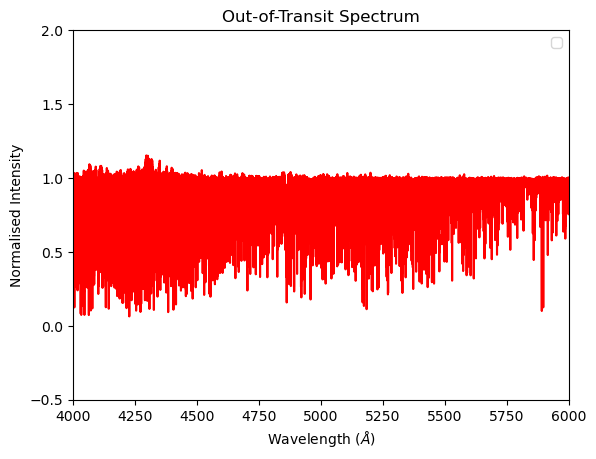

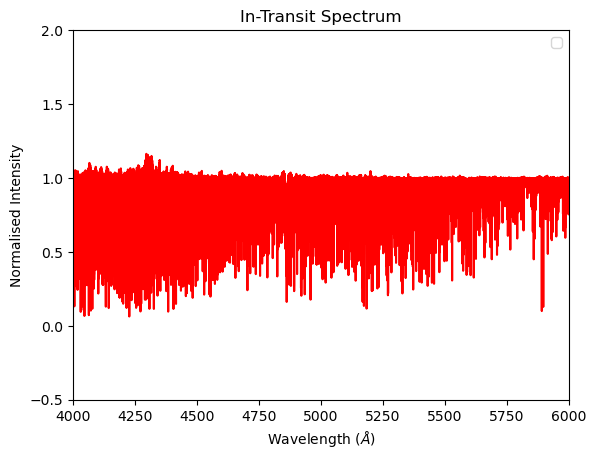

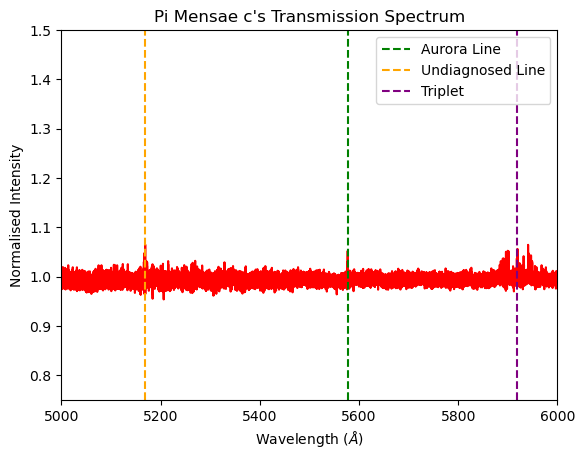

In [38]:
def get_orders(file):
    orders, jD = extractOrdersFromFile(spectraDir+file)
    normalisedOrders = normaliseOrders(orders, scale=20, intensityLimit = 20.0,polynomialOrder = 4)
    combinedOrders = combineOrders(normalisedOrders)
    return orders, normalisedOrders, combinedOrders

# plt.figure()
# for file in spectraFileList:
#     _,_,orders = get_orders(file)
#     wavelengths,fluxes = orders
#     plt.plot(wavelengths, fluxes, label=file)
#     plt.xlim(5000, 5500)
#     plt.ylim(-1,2)
#     print(wavelengths)
    
# plt.legend()
# plt.show()


XLIMS = [[5750,6000],[5875, 5960],[6250,6350]][1]
P_YLIMS = [[0.75,1.5],[-0.1, 0.1]][0]
YLIMS=[-0.5,2]
TRIPLET=[5919]
AURORA=[5577.25]
"""   OUT OF TRANSIT STUFF   """
ootOrders = [file for file in spectraFileList[:3]]
itOrders = [file for file in spectraFileList[3:]]
ootCombined = []
for i, ootOrder in enumerate(ootOrders):
    orders, normalisedOrders, combinedOrders = get_orders(ootOrder)
    if i == 0:
        template_wave = combinedOrders[0]
    interp_flux = np.interp(template_wave, combinedOrders[0], combinedOrders[1])
    ootCombined.append(interp_flux)
#     SpectrumPlot([[combinedOrders]],['Combined Orders'],figure_num=1)
median_flux0 = np.median(ootCombined, axis=0)
plt.figure(1)
axes = plt.axes()
axes.set_xlim(4000,6000)
# axes.set_xlim(XLIMS)
axes.set_ylim(YLIMS)
axes.plot(template_wave,median_flux0, c='r')
# axes.axvline(AURORA, c='g',label='Aurora Line', linestyle='--')
# axes.axvline(5169,c='orange', linestyle='--')
# axes.axvline(TRIPLET,c='purple',label='Triplet', linestyle='--')
axes.legend()
axes.set_title("Out-of-Transit Spectrum")
axes.set_ylabel("Normalised Intensity")
axes.set_xlabel("Wavelength ($\AA$)")

"""   IN TRANSIT STUFF   """

itCombined = []
for i, itOrder in enumerate(itOrders):
    orders, normalisedOrders, combinedOrders = get_orders(itOrder)
    interp_flux = np.interp(template_wave, combinedOrders[0], combinedOrders[1])
    itCombined.append(interp_flux)
    interp_flux = np.interp(template_wave, combinedOrders[0], combinedOrders[1])
#     SpectrumPlot([[combinedOrders]],['Combined Orders'], xlim = [6560,6565],figure_num=2)
median_flux1 = np.median(itCombined, axis=0)
plt.figure(2)
axes = plt.axes()
axes.set_ylim(YLIMS)
axes.set_xlim(4000,6000)
# axes.set_xlim(XLIMS)
axes.plot(template_wave,median_flux1, c='r')
axes.set_title("In-Transit Spectrum")
axes.set_ylabel("Normalised Intensity")
axes.set_xlabel("Wavelength ($\AA$)")
# axes.axvline(AURORA, c='g',label='Aurora Line', linestyle='--')
# axes.axvline(5169,c='orange', linestyle='--')
# axes.axvline(TRIPLET,c='purple',label='Triplet', linestyle='--')
axes.legend()
             
"""   PLANET STUFF   """
planet = median_flux0 / median_flux1 # star / transit
plt.figure(3)
axes = plt.axes()
axes.set_xlim(5000,6000)
axes.set_ylim(P_YLIMS)
axes.plot(template_wave,planet, c='r')
axes.axvline(AURORA, c='g',label='Aurora Line', linestyle='--')
axes.axvline(5169,c='orange', linestyle='--', label='Undiagnosed Line')
axes.axvline(TRIPLET,c='purple',label='Triplet', linestyle='--')
axes.legend()
axes.set_title("Pi Mensae c's Transmission Spectrum")
axes.set_ylabel("Normalised Intensity")
axes.set_xlabel("Wavelength ($\AA$)")
star_spectrum = [template_wave, median_flux0]
np.save('star_spectrum.npy', star_spectrum)

[14784.29710721 11287.65029163 10586.11517877 11526.80175968
 11498.61160391 11602.28467904  9067.20569467 11103.68821553
 11602.70884884 11337.93325133 11872.20138955 11477.93650304
 11681.88232343 11477.7132209  11433.86970311 10279.93006518
  9995.7924797   9995.7924797   8865.91752118  7225.19847525
 12233.9161033  11304.76596071 12007.88852526 11840.35357055
 10839.53100954 10226.27181016 11198.9996524  11004.25211293
 12669.05902375 11386.98366249 11477.24870826 11206.47967839
 11051.17784297 11620.17436391 24814.34990328 10945.8744697
 10926.8253899  12679.06951192  8535.46836959 10140.84973122
  6809.07685735  5364.41396783 12134.29089335 12026.2610968
 11326.79500972 11720.67243176 10308.89278987 11361.50934928
 11139.06348167 11529.45737662  9144.7881881  11273.32858822
 11738.94970968  8263.76180212 12209.48099003 10674.16316328
 11532.96658513 11446.65170617 10823.63965452 11336.12294945
 10923.09688652  7749.41107317]
11091.12685068584
11315.780485217168


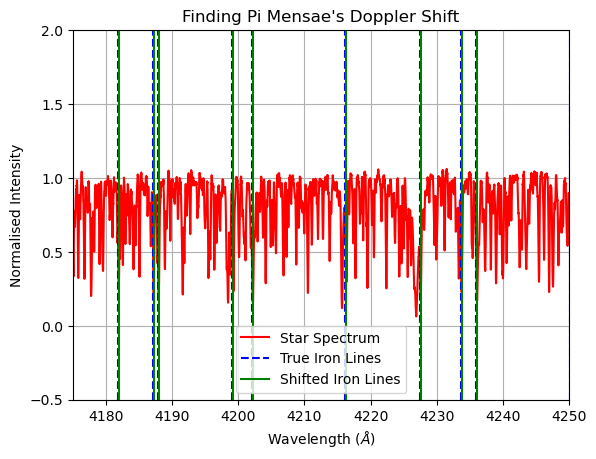

In [25]:
#now to correct for radial velocity
# picking a few iron lines (strong)
real_fe_lines = 10 * np.array([418.17544, 418.70387, 418.77952, 419.9095, 420.20289, 421.61835, 422.74263, 423.36025, 423.59367, 425.01192, 425.07866, 426.04741, 427.11535, 427.17602, 428.24026, 429.41245, 429.9235, 429.9235, 430.79020, 431.50843, 432.57616, 437.59298, 438.35447, 440.47501, 441.51222, 442.73096, 446.16525, 446.65515, 452.86139, 487.13179, 489.07548, 489.14921, 491.89937,
                              492.05028, 495.72983, 495.75965, 500.61188, 501.20681,
                               504.17557, 511.04128, 513.94625, 516.74881, 517.15960,
                               519.23439, 519.49414, 521.62737, 522.71891, 523.29400,
                               526.65550, 526.95370, 527.03560, 532.41787, 532.80383,
                               532.85313, 534.10237, 537.14893, 539.71276, 540.57749,
                               542.96964, 543.45235, 544.69164, 545.56092]) 

shifted_lines = []
# finding peaks for each line near its location
for line in real_fe_lines:
    params = fitGaussianLine([template_wave, median_flux0], [line, line+0.5])
    params = params.to_numpy()
    shifted_lines.append([params[0][1],params[0][5]])

axes = plt.axes()
axes.set_xlim(4175,4250)
axes.grid(True)
axes.set_ylim(YLIMS)
axes.plot(template_wave,median_flux0, c='r',label='Star Spectrum')
for i, line in enumerate(real_fe_lines):
    if i == 0:
        axes.axvline(line, linestyle='--', label='True Iron Lines', c='blue')
    else:
        axes.axvline(line, linestyle='--',c='blue')
    

for i, line in enumerate(shifted_lines):
    if i == 0:
        axes.axvline(line[0], c='green', label='Shifted Iron Lines')
    else:
        axes.axvline(line[0], c='green')
axes.set_title("Finding Pi Mensae's Doppler Shift")

axes.legend()
axes.set_ylabel("Normalised Intensity")
axes.set_xlabel("Wavelength ($\AA$)")
# now to calculate our velocities from the wavelength change
def doppler_velocity(real, obs):
    # return radial velocity from a doppler shift
    return ((obs - real)*3*10**8)/real

velocities = doppler_velocity(real_fe_lines / 10**10, np.array(shifted_lines)[:,0]/10**10)
print(velocities)
print(np.mean(velocities))
print(np.median(velocities))
star_flux = median_flux0



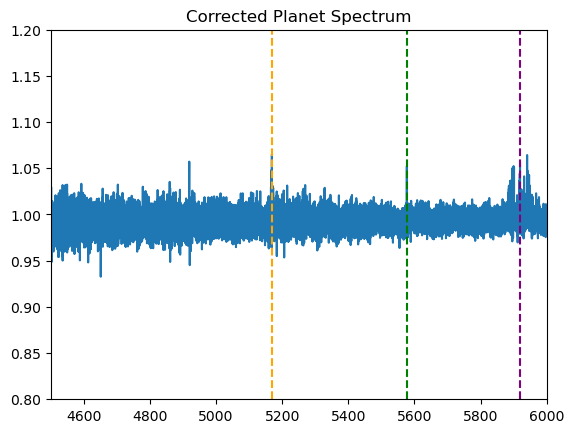

In [6]:
# now to correct our planet spectrum
spectrum = {'waveobs':template_wave}

corrected_spectrum = correct_velocity(spectrum, np.median(velocities) / 1000)

wavelength = corrected_spectrum['waveobs']

corrected_wavelength = wavelength

star_spectrum = [corrected_wavelength, median_flux0]
np.save('star_spectrum.npy', star_spectrum)
plt.plot(wavelength, planet)
plt.ylim(0.8,1.2)
plt.xlim(4500,6000)
plt.title("Corrected Planet Spectrum")
plt.axvline(AURORA, c='g',label='Aurora Line', linestyle='--')
plt.axvline(5169,c='orange', linestyle='--')
plt.axvline(TRIPLET,c='purple',label='Triplet', linestyle='--')
plt.show()

In [1]:
def interpolate_spectra(template_spectrum, old_spectrum):
    template_wavelength = template_spectrum[0]
    old_wavelength, old_flux = old_spectrum
    interp_flux = np.interp(template_wavelength, old_wavelength, old_flux)
    return interp_flux

def chi_squared(model_spectrum, real_spectrum):
    model_flux = model_spectrum[1]
    real_flux = real_spectrum[1]
    print(model_flux, real_flux)
    return sum([(real - model)**2 / model for real, model in zip(real_flux, model_flux)])
import os

def get_spectrum(file):
    hdul = fits.open(file)
    data = hdul[1].data
    hdul.close()
    flux = []
    wavelength = []
    for tup in data:
        flux.append(float(tup[2]))
        wavelength.append(float(tup[0]))
    return [wavelength, flux]
    
